# 06 — Suffix Attribution Heatmap (Camargo Helpdesk)

Port of the henryk `06_suffix_attribution_heatmap` notebook for the Camargo baseline.

Camargo is a single-step predictor, so there is no real 'suffix over multiple decoder steps'. Instead we pick a case + prefix length, then roll the prediction forward one activity at a time (greedy auto-regressive), computing Integrated Gradients at every step with respect to the predicted class at that step. The heatmap rows are features (Activity embedding, Resource embedding, case_elapsed_time) and the columns are prefix positions (padded-left, so the last column is the most recent event).

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

SPEC = utils.HELPDESK_SHAREDCAT_ROLES_NGRAM
model = utils.load_camargo_model(_current, SPEC)
dataset = utils.load_test_dataset(_current, SPEC)
window = SPEC.ngram_size or utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)
idx_to_name = predictor.idx_to_name
eos_idx = predictor.eos_idx
ACT_IDX = SPEC.cat_indices[0]
RES_IDX = SPEC.cat_indices[1]
CET_IDX = SPEC.num_indices[0]
feature_names = ['Activity', 'Resource', 'case_elapsed_time']
print(f'{SPEC.name} | window={window}')

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Role', 9, {'EOS': 1, 'Role_1': 2, 'Role_2': 3, 'Role_3': 4, 'Role_4': 5, 'Role_5': 6, 'Role_6': 7, 'Role_7': 8})], [('case_elapsed_time', 1, {})])
Model input features:  [['Activity', 'Role'], ['case_elapsed_time']]
Embeddings:  ModuleList(
  (0): Embedding(16, 8)
  (1): Embedding(9, 5)
)
Total embedding feature size:  13
Number of numerical features:  1
Input feature size (shared LSTM, cat-only):  13
Cells hidden size:  50
Number of LSTM layer:  1


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Helpdesk (SharedCat + Roles, n-gram=5) | window=5


## Config

In [2]:
CASE_NAME = 'Case 1016'   # change to any test case
PREFIX_LENGTH = 1         # prefix length to analyse
MAX_SUFFIX_STEPS = 6      # how many auto-regressive steps to roll
IG_STEPS = 50

In [3]:
cats_full = nums_full = None
for i in range(len(dataset)):
    if dataset[i][2] == CASE_NAME:
        cats_full, nums_full, _ = dataset[i]
        break
if cats_full is None:
    raise ValueError(f'Case {CASE_NAME!r} not found in test set')
acts_raw = cats_full[ACT_IDX].tolist()
nonzero = [i for i, a in enumerate(acts_raw) if a != 0]
start = nonzero[0]
useful_len = len(nonzero)
while useful_len > 0 and acts_raw[start + useful_len - 1] == eos_idx:
    useful_len -= 1
print(f'Case {CASE_NAME} | activities: {[idx_to_name.get(acts_raw[start + k]) for k in range(useful_len)]}')

Case Case 1016 | activities: ['Assign seriousness', 'Take in charge ticket', 'Resolve ticket', 'Closed']


In [4]:
# Auto-regressive rollout starting from the prefix. At every step compute IG.
cats_win, nums_win = utils.make_prefix_window(
    cats_full, nums_full, start=start, prefix_length=PREFIX_LENGTH,
    window=window, spec=SPEC,
)
heatmaps = []  # list of (target_class_name, feat_matrix [n_features, window], prefix_labels)
cur_cats = [c.clone() for c in cats_win]
cur_nums = [n.clone() for n in nums_win]
for step in range(MAX_SUFFIX_STEPS):
    pred_idx, probs = predictor.predict_batch(cur_cats, cur_nums)
    target = int(pred_idx.item())
    target_name = idx_to_name.get(target, f'<{target}>')
    cat_attrs, num_attrs = utils.compute_integrated_gradients(
        model, cur_cats, cur_nums, target_class=target, n_steps=IG_STEPS
    )
    mat = utils.attributions_to_matrix(cat_attrs, num_attrs, feature_names).numpy()
    # Column labels: name of activity at each position, <pad> for empty slots
    acts_window_values = cur_cats[0][0].tolist()
    col_labels = [idx_to_name.get(a, '<pad>') if a != 0 else '<pad>' for a in acts_window_values]
    heatmaps.append({'step': step, 'target': target_name, 'confidence': float(probs[0, target].item()),
                     'mat': mat, 'col_labels': col_labels})
    if target_name == 'EOS':
        break
    # Roll window left by 1 and drop-in the predicted activity at the last slot
    cur_cats[0] = torch.cat([cur_cats[0][:, 1:], torch.tensor([[target]], dtype=cur_cats[0].dtype)], dim=1)
    # Keep resource and case_elapsed_time rolling from ground truth if available
    gt_pos = start + PREFIX_LENGTH + step
    if gt_pos < start + useful_len:
        cur_cats[1] = torch.cat([cur_cats[1][:, 1:], cats_full[RES_IDX][gt_pos].view(1, 1)], dim=1)
        cur_nums[0] = torch.cat([cur_nums[0][:, 1:], nums_full[CET_IDX][gt_pos].view(1, 1)], dim=1)
    else:
        cur_cats[1] = torch.cat([cur_cats[1][:, 1:], torch.zeros(1, 1, dtype=cur_cats[1].dtype)], dim=1)
        cur_nums[0] = torch.cat([cur_nums[0][:, 1:], torch.zeros(1, 1, dtype=cur_nums[0].dtype)], dim=1)
print(f'Generated {len(heatmaps)} IG heatmaps')

RuntimeError: input.size(-1) must be equal to input_size. Expected 13, got 14

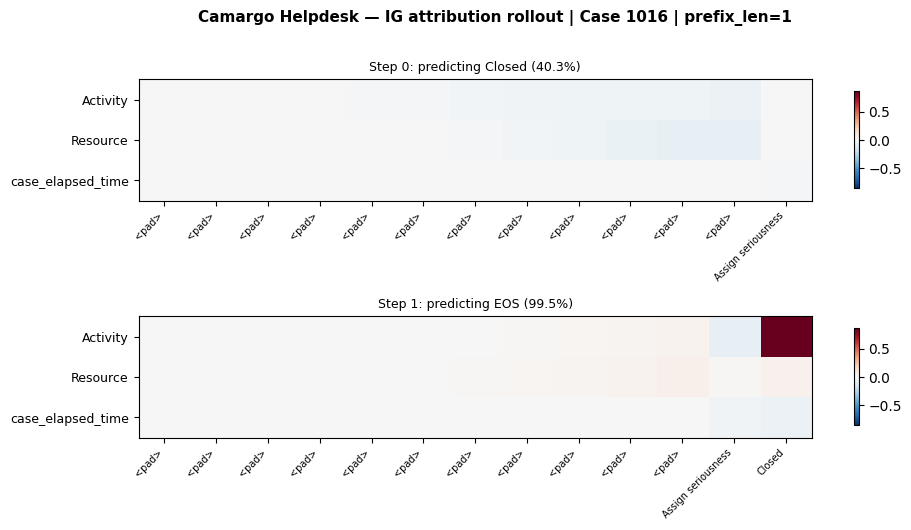

In [ ]:
n = len(heatmaps)
fig, axes = plt.subplots(n, 1, figsize=(10, 2 + 1.6 * n), squeeze=False)
all_vmax = max((np.abs(h['mat']).max() for h in heatmaps), default=1.0) or 1.0
for i, h in enumerate(heatmaps):
    ax = axes[i, 0]
    norm = TwoSlopeNorm(vmin=-all_vmax, vcenter=0, vmax=all_vmax)
    im = ax.imshow(h['mat'], cmap='RdBu_r', aspect='auto', norm=norm, interpolation='nearest')
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(feature_names, fontsize=9)
    ax.set_xticks(range(len(h['col_labels'])))
    ax.set_xticklabels(h['col_labels'], rotation=45, ha='right', fontsize=7)
    ax.set_title(f"Step {h['step']}: predicting {h['target']} ({h['confidence']*100:.1f}%)", fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle(f"Camargo {SPEC.name} — IG attribution rollout | {CASE_NAME} | prefix_len={PREFIX_LENGTH}",
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Per-feature total |attribution| across all rollout steps
import pandas as pd
totals = np.sum(np.stack([np.abs(h['mat']).sum(axis=1) for h in heatmaps], axis=0), axis=0)
summary = pd.DataFrame({'Feature': feature_names, 'Total |attribution|': totals}).sort_values('Total |attribution|', ascending=False)
summary

,Feature,Total |attribution|
0,Activity,1.259787
1,Resource,0.451618
2,case_elapsed_time,0.101187
